In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False


In [2]:
df = pd.read_csv("../data/07-9_bike_ttareungi.csv")
df

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,202606,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621
1,202606,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
2,202606,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148
3,202606,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,202606,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220
...,...,...,...,...,...,...,...,...,...,...,...
4995,202606,4625,4625. 용산공원갤러리앞,일일권(3시간),M,20대,1,56.76,0.51,2205.05,148
4996,202606,239,239. 유스호스텔 앞,일일권(비회원),NaN,30대,1,NaN,NaN,0.00,7
4997,202606,3116,3116.신촌역 4번출구,정기권,M,50대,37,2183.44,19.42,83796.47,1639
4998,202606,281,281. 대림신동아아파트 앞,정기권,F,60대,18,429.06,3.91,16668.52,167


### 2. 데이터 정보 확인
- 행, 열 갯수
- 결측치
- 타입 체크

In [3]:
df.shape

(5000, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   대여일자     5000 non-null   int64  
 1   대여소번호    5000 non-null   int64  
 2   대여소명     5000 non-null   str    
 3   대여구분코드   5000 non-null   str    
 4   성별       3188 non-null   str    
 5   연령대코드    5000 non-null   str    
 6   이용건수     5000 non-null   int64  
 7   운동량      4992 non-null   float64
 8   탄소량      4992 non-null   float64
 9   이동거리(M)  5000 non-null   float64
 10  이용시간(분)  5000 non-null   int64  
dtypes: float64(3), int64(4), str(4)
memory usage: 429.8 KB


In [5]:
# 결측치 확인
df.isna().sum()

대여일자          0
대여소번호         0
대여소명          0
대여구분코드        0
성별         1812
연령대코드         0
이용건수          0
운동량           8
탄소량           8
이동거리(M)       0
이용시간(분)       0
dtype: int64

In [13]:
# 월 항목 필요
#df['월'] = df['대여일자'].astype("str").apply( lambda x: x[-2:] )
df['대여일자'] = pd.to_datetime(df["대여일자"], format="%Y%M")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   대여일자     5000 non-null   datetime64[us]
 1   대여소번호    5000 non-null   int64         
 2   대여소명     5000 non-null   str           
 3   대여구분코드   5000 non-null   str           
 4   성별       3188 non-null   str           
 5   연령대코드    5000 non-null   str           
 6   이용건수     5000 non-null   int64         
 7   운동량      4992 non-null   float64       
 8   탄소량      4992 non-null   float64       
 9   이동거리(M)  5000 non-null   float64       
 10  이용시간(분)  5000 non-null   int64         
 11  월        5000 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(3), str(5)
memory usage: 468.9 KB


In [14]:
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
0,2026-01-01 00:06:00,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,06
1,2026-01-01 00:06:00,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,06
2,2026-01-01 00:06:00,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,06
3,2026-01-01 00:06:00,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,06
4,2026-01-01 00:06:00,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,06


In [11]:
df['월'].unique()

<StringArray>
['06']
Length: 1, dtype: str

In [15]:
df.drop("월",axis=1)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2026-01-01 00:06:00,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621
1,2026-01-01 00:06:00,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
2,2026-01-01 00:06:00,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148
3,2026-01-01 00:06:00,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,2026-01-01 00:06:00,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220
...,...,...,...,...,...,...,...,...,...,...,...
4995,2026-01-01 00:06:00,4625,4625. 용산공원갤러리앞,일일권(3시간),M,20대,1,56.76,0.51,2205.05,148
4996,2026-01-01 00:06:00,239,239. 유스호스텔 앞,일일권(비회원),NaN,30대,1,NaN,NaN,0.00,7
4997,2026-01-01 00:06:00,3116,3116.신촌역 4번출구,정기권,M,50대,37,2183.44,19.42,83796.47,1639
4998,2026-01-01 00:06:00,281,281. 대림신동아아파트 앞,정기권,F,60대,18,429.06,3.91,16668.52,167


In [17]:
# df.head(3)
df = df.drop("월",axis=1)

In [19]:
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2026-01-01 00:06:00,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621
1,2026-01-01 00:06:00,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
2,2026-01-01 00:06:00,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148
3,2026-01-01 00:06:00,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,2026-01-01 00:06:00,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220


In [20]:
df['월'] = df['대여일자'].dt.month

In [22]:
#df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   대여일자     5000 non-null   datetime64[us]
 1   대여소번호    5000 non-null   int64         
 2   대여소명     5000 non-null   str           
 3   대여구분코드   5000 non-null   str           
 4   성별       3188 non-null   str           
 5   연령대코드    5000 non-null   str           
 6   이용건수     5000 non-null   int64         
 7   운동량      4992 non-null   float64       
 8   탄소량      4992 non-null   float64       
 9   이동거리(M)  5000 non-null   float64       
 10  이용시간(분)  5000 non-null   int64         
 11  월        5000 non-null   int32         
dtypes: datetime64[us](1), float64(3), int32(1), int64(3), str(4)
memory usage: 449.3 KB


In [23]:
df.describe()

,대여일자,대여소번호,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
count,5000,5000.000000,5000.000000,4992.000000,4992.000000,5.000000e+03,5000.000000,5000.0
mean,2026-01-01 00:06:00,2469.606200,35.068600,2225.499677,20.032061,8.657075e+04,750.170000,1.0
min,2026-01-01 00:06:00,102.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000,1.0
25%,2026-01-01 00:06:00,1002.750000,2.000000,200.442500,1.800000,7.757700e+03,73.000000,1.0
50%,2026-01-01 00:06:00,2127.500000,10.000000,699.620000,6.305000,2.720835e+04,235.000000,1.0
75%,2026-01-01 00:06:00,4017.250000,36.000000,2377.105000,21.397500,9.265690e+04,806.000000,1.0
max,2026-01-01 00:06:00,6190.000000,834.000000,91128.270000,820.500000,3.541931e+06,21055.000000,1.0
std,NaN,1690.504556,68.441332,4366.479313,39.298029,1.698710e+05,1393.779575,0.0


In [27]:
df.isna().sum()

대여일자          0
대여소번호         0
대여소명          0
대여구분코드        0
성별         1806
연령대코드         0
이용건수          0
운동량           0
탄소량           0
이동거리(M)       0
이용시간(분)       0
월             0
dtype: int64

In [26]:
# 운동량과 탄소량 몇개 안되니까 제거
df = df.dropna(subset=["운동량",'탄소량'])

In [28]:
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
0,2026-01-01 00:06:00,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,1
1,2026-01-01 00:06:00,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,1
2,2026-01-01 00:06:00,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,1
3,2026-01-01 00:06:00,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,1
4,2026-01-01 00:06:00,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,1


In [31]:
df['성별'].unique()

<StringArray>
['미상', 'M', 'F']
Length: 3, dtype: str

In [30]:
df['성별'] = df['성별'].fillna("미상")


In [32]:
df['성별'].value_counts()

성별
미상    1806
M     1681
F     1505
Name: count, dtype: int64

In [33]:
df.head(3)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
0,2026-01-01 00:06:00,1201,1201. 가락시장역 3번 출구,정기권,미상,30대,123,8750.55,78.97,339960.75,2621,1
1,2026-01-01 00:06:00,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,1
2,2026-01-01 00:06:00,3928,3928.고척아이파크아파트 106동 앞,일일권,미상,40대,7,444.12,4.00,17254.05,148,1


In [36]:
df["운동량/건별"] = (df["운동량"] / df["이용건수"]).round(2)
df["탄소량/건별"] = (df["탄소량"] / df["이용건수"]).round(2)
df["이동거리(M)/건별"] = (df["이동거리(M)"] / df["이용건수"]).round(2)
df["이용시간(분)/건별"] = (df["이용시간(분)"] / df["이용건수"]).round(2)

In [38]:
df.head(3)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-01-01 00:06:00,1201,1201. 가락시장역 3번 출구,정기권,미상,30대,123,8750.55,78.97,339960.75,2621,1,71.14,0.64,2763.91,21.31
1,2026-01-01 00:06:00,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,1,34.50,0.31,1340.52,11.53
2,2026-01-01 00:06:00,3928,3928.고척아이파크아파트 106동 앞,일일권,미상,40대,7,444.12,4.00,17254.05,148,1,63.45,0.57,2464.86,21.14


In [39]:
# 연령대 코드
df['연령대코드'].unique()

<StringArray>
['30대', '~10대', '40대', '50대', '20대', '60대', '기타', '70대이상']
Length: 8, dtype: str

In [40]:
(df['연령대코드'] == "기타").sum()

np.int64(426)

In [45]:
df.query("연령대코드 == '기타'").sum(numeric_only=True)

대여소번호          1022359.00
이용건수              3605.00
운동량             256955.47
탄소량               2324.12
이동거리(M)       10074135.52
이용시간(분)          93065.00
월                  426.00
운동량/건별           41697.74
탄소량/건별             376.36
이동거리(M)/건별     1627935.25
이용시간(분)/건별       14474.14
dtype: float64

In [48]:
df.query("   연령대코드 == '기타'   ")["연령대코드"].count()

np.int64(426)

In [61]:
# 1 
gender_data = df.groupby("성별")[['이동거리(M)/건별','이용시간(분)/건별']].mean().reset_index()
gender_data

,성별,이동거리(M)/건별,이용시간(분)/건별
0,F,3395.072512,31.711701
1,M,3529.823575,29.988667
2,미상,3442.849385,29.637697


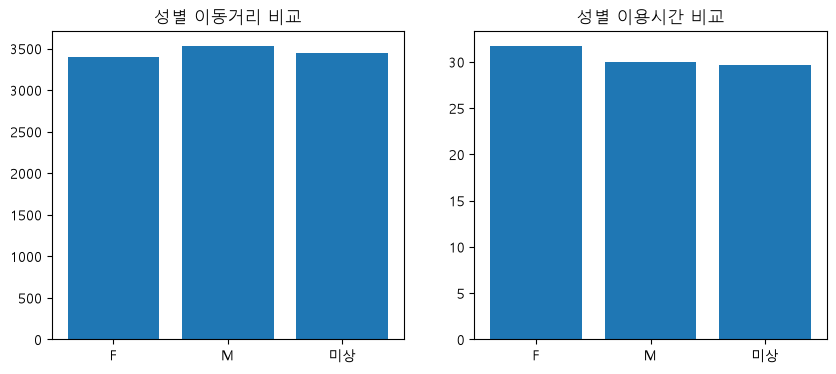

In [64]:
# 시각화
fig, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].bar(
                gender_data['성별'],
                gender_data['이동거리(M)/건별']
            )

axes[0].set_title("성별 이동거리 비교")

axes[1].bar(
                gender_data['성별'],
                gender_data['이용시간(분)/건별']                

            )

axes[1].set_title("성별 이용시간 비교")

plt.show()

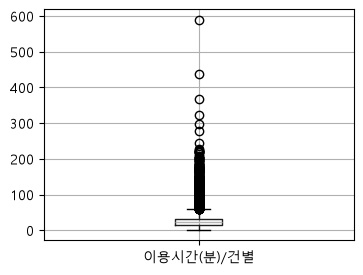

In [67]:
plt.figure(figsize=(4,3))
df.boxplot(column="이용시간(분)/건별")
plt.show()

In [68]:
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-01-01 00:06:00,1201,1201. 가락시장역 3번 출구,정기권,미상,30대,123,8750.55,78.97,339960.75,2621,1,71.14,0.64,2763.91,21.31
1,2026-01-01 00:06:00,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,1,34.50,0.31,1340.52,11.53
2,2026-01-01 00:06:00,3928,3928.고척아이파크아파트 106동 앞,일일권,미상,40대,7,444.12,4.00,17254.05,148,1,63.45,0.57,2464.86,21.14
3,2026-01-01 00:06:00,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,1,181.72,1.64,7060.00,66.00
4,2026-01-01 00:06:00,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,1,110.10,0.99,4277.63,36.67


In [69]:
df[df['대여소번호'] == 1201].count()

대여일자          5
대여소번호         5
대여소명          5
대여구분코드        5
성별            5
연령대코드         5
이용건수          5
운동량           5
탄소량           5
이동거리(M)       5
이용시간(분)       5
월             5
운동량/건별        5
탄소량/건별        5
이동거리(M)/건별    5
이용시간(분)/건별    5
dtype: int64

In [70]:
df['이동거리(M)/건별'].max()

np.float64(80516.87)

In [71]:
df[df['이동거리(M)/건별'] == 80516.87]

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
2104,2026-01-01 00:06:00,2094,2094.숭실대학교(중문),일일권(비회원 3시간),미상,기타,1,2072.5,18.68,80516.87,589,1,2072.5,18.68,80516.87,589.0


In [75]:
df[df['이동거리(M)/건별'] > 30000 ].sort_values(by="이동거리(M)/건별", ascending=False)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
2104,2026-01-01 00:06:00,2094,2094.숭실대학교(중문),일일권(비회원 3시간),미상,기타,1,2072.50,18.68,80516.87,589,1,2072.50,18.68,80516.87,589.0
3919,2026-01-01 00:06:00,1858,"1858. 500번,507번 버스 종점 앞",일일권(3시간),M,20대,1,1375.75,12.40,53448.09,121,1,1375.75,12.40,53448.09,121.0
4257,2026-01-01 00:06:00,869,869.노들섬 동측 앞,일일권(3시간),M,~10대,1,1086.88,9.80,42225.38,178,1,1086.88,9.80,42225.38,178.0
2816,2026-01-01 00:06:00,1158,1158. 가양역 8번출구,일일권(3시간),미상,40대,2,1995.86,17.99,77539.29,345,1,997.93,8.99,38769.64,172.5
276,2026-01-01 00:06:00,1708,1708. 도봉보건소사거리,일일권(3시간),M,40대,4,3735.61,33.66,145128.57,772,1,933.90,8.41,36282.14,193.0
4973,2026-01-01 00:06:00,912,912. 응암오거리,일일권(3시간),M,~10대,2,1792.29,16.16,69630.38,262,1,896.14,8.08,34815.19,131.0
1728,2026-01-01 00:06:00,4618,4618. 풍전아파트 건너편,일일권(3시간),M,50대,1,888.79,8.01,34529.37,131,1,888.79,8.01,34529.37,131.0
2194,2026-01-01 00:06:00,4098,4098.창동역 1번출구 인근,일일권(3시간),미상,기타,1,880.57,7.94,34210.00,124,1,880.57,7.94,34210.00,124.0
4165,2026-01-01 00:06:00,4693,4693. 수색감리교회,일일권(3시간),F,30대,1,860.28,7.75,33421.93,152,1,860.28,7.75,33421.93,152.0
1794,2026-01-01 00:06:00,2091,2091. 이수역9번출구,일일권,F,50대,1,851.60,7.68,33084.52,167,1,851.60,7.68,33084.52,167.0


In [3]:
df_1_6 = pd.read_csv("../data/서울특별시 공공자전거 이용정보(월별)_26.1-6.csv", encoding="cp949")
df_1_6

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,202601,102,102. 망원역 1번출구 앞,일일권,NaN,20대,7,313.42,2.76,11927.89,82
1,202601,102,102. 망원역 1번출구 앞,일일권,NaN,30대,15,680.77,6.57,28380.64,281
2,202601,102,102. 망원역 1번출구 앞,일일권,NaN,40대,5,281.56,2.60,11177.03,112
3,202601,102,102. 망원역 1번출구 앞,일일권,NaN,50대,1,46.27,0.36,1537.28,10
4,202601,102,102. 망원역 1번출구 앞,일일권,F,20대,40,2288.99,20.31,89410.71,806
...,...,...,...,...,...,...,...,...,...,...,...
655811,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,50대,101,2924.79,25.97,112158.08,915
655812,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,60대,26,955.09,8.57,37105.05,302
655813,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,70대이상,10,314.59,2.84,12221.50,132
655814,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,~10대,31,1244.79,11.12,48014.67,446


In [9]:
df_1_6['대여일자'] = pd.to_datetime( df_1_6['대여일자'], format="%Y%m")
df_1_6['월'] = df_1_6['대여일자'].dt.month
df_1_6.head(3)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
0,2026-01-01,102,102. 망원역 1번출구 앞,일일권,NaN,20대,7,313.42,2.76,11927.89,82,1
1,2026-01-01,102,102. 망원역 1번출구 앞,일일권,NaN,30대,15,680.77,6.57,28380.64,281,1
2,2026-01-01,102,102. 망원역 1번출구 앞,일일권,NaN,40대,5,281.56,2.60,11177.03,112,1


In [10]:
monthly = df_1_6.groupby("월")["이용건수"].sum()
monthly

월
1    1595817
2    1744693
3    2842284
4    3824308
5    3905121
6    4066671
Name: 이용건수, dtype: int64